### 統計學習與深度學習 (Fall, 2024)
### Homework 1

請將IPYNB檔與IPYNB Export之HTML檔上傳至COOL作業區。作業自己做。嚴禁抄襲。不接受紙本繳交，不接受遲交。請以英文或中文作答。
如無其他規定，所有重要結果應顯示至小數點第四位(四捨五入)。本次作業盡可能使用scikit-learn的函數與numpy進行實作。禁止使用Auto-SKlearn或其他AutoML工具。


### 第一題 [Ridge Regression Baseline]

(30%) 以Ridge Regression進行房價預測。Regularizaiton coefficient (alphas)應考慮介於0.01至100之間的數值，且至少應考慮十種可能的數值。

訓練資料檔案為'housing_5cities_train.csv', 測試資料檔案為 'housing_5cities_testa.csv'。預測標的為'單價'。你的模型應包含以下特徵:
* 建物面積
* 總樓層數
* 屋齡
* 縣市
* 鄉鎮市區
* 主要用途
* 主要建材
* 建物型態

類別型特徵應進行適當的轉換。

(1) 畫出高雄市資料點的分布，橫坐標為x軸，縱坐標為y軸。依照單價將資料點上色。說明你對資料點個觀察。

(2) 列出最終選用的Regularization Coefficient，以下模型參數，並報告模型在測試資料的預測能力 (包含R2、RMSE、MAE、MAPE)。
* Constant term coefficient
* 建物面積
* 總樓層數
* 屋齡
* 台中市
* 台北市
* 新北市
* 桃園市
* 高雄市

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import random
import matplotlib.pyplot as plt


from sklearn.preprocessing import OneHotEncoder

# %matplotlib inline

pd.set_option('display.max_column', 500)
pd.set_option('display.max_rows', 5000)
random.seed(1001)

In [3]:
# training data
dftrain = pd.read_csv('./housing_5cities_train.csv')
# test data
dftesta = pd.read_csv('./housing_5cities_testa.csv')
print(f"Training df shape = {dftrain.shape}; test df shape = {dftesta.shape}")

Training df shape = (8140, 21); test df shape = (1031, 21)


(1)



 畫出高雄市資料點的分布，橫坐標為x軸，縱坐標為y軸。依照單價將資料點上色。說明你對資料點個觀察。


In [5]:
plt.rcParams['font.family']=['Arial Unicode MS']

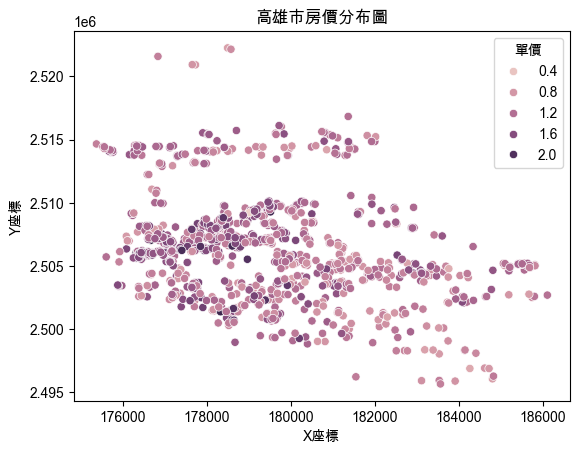

In [6]:
kaohsiung_data = dftrain[dftrain['縣市'] == '高雄市']
sns.scatterplot(kaohsiung_data, x="橫坐標", y="縱坐標", hue = "單價")

# 調整圖表
plt.title('高雄市房價分布圖')
plt.xlabel('X座標')
plt.ylabel('Y座標')
plt.legend(title='單價')
plt.show()

從這張高雄市房價分布圖來看，我們可以觀察到以下幾點：

房價集中帶： 大部分的資料點集中在Y軸2500-2510之間，這表示高雄市的主要房子落在這個範圍內。
高房價區域： 在X軸176000-180000、Y軸2500-2510的區域，資料點的顏色較深，代表這個區域的房價相對較高。
    

In [7]:

def gen_features(dftrain, dftest, numfeatures, catfeatures, enc):


    X_train = dftrain[numfeatures].to_numpy()    
    enc.fit(dftrain[catfeatures])
    X_train_cat = enc.transform(dftrain[catfeatures]).toarray()
    X_train2 = np.hstack((X_train, X_train_cat))

    X_test = dftesta[numfeatures].to_numpy()
    X_test_cat = enc.transform(dftesta[catfeatures]).toarray()
    X_test2 = np.hstack((X_test, X_test_cat))

    return X_train2, X_test2

def get_performance(X, y, beta):

    y_mean = np.mean(y)
    SST = np.sum((y - y_mean) ** 2)
   
    c0 = np.ones((X.shape[0], 1))
    X = np.hstack((c0, X))  
    yhead = X @ beta
    error = yhead - y
    SSE = np.sum(error ** 2)
    MAE = np.mean(abs(error))
    RMSE = (np.mean(error ** 2)) ** 0.5
    MAPE = np.mean(abs(error / y))
    
    return 1 - SSE / SST, RMSE, MAE, MAPE

In [8]:

def fit_ridge_reg(X_train, y_train, lam, reg_intercept = False):

   
    c0 = np.ones((X_train.shape[0], 1))
    X_train = np.hstack((c0, X_train))
    lamI = np.eye(X_train.shape[1]) * lam
    if not reg_intercept:
        lamI[0,0] = 0
    # print(lamI)
    beta_head = np.linalg.inv(np.transpose(X_train) @ X_train + lamI) @ np.transpose(X_train) @ y_train
    return beta_head





(2) 列出最終選用的Regularization Coefficient，以下模型參數，並報告模型在測試資料的預測能力 (包含R2、RMSE、MAE、MAPE)。
* Constant term coefficient
* 建物面積
* 總樓層數
* 屋齡
* 台中市
* 台北市
* 新北市
* 桃園市
* 高雄市

In [9]:
numfeatures = ['建物面積', '總樓層數', '屋齡']
catfeatures = ['縣市', '鄉鎮市區', '主要用途', '主要建材', '建物型態']
targetfeature=['台中市' ,'台北市','新北市', '桃園市', '高雄市',"Const."]
measurefeature=['R2',"MAE","MAPE",'RMSE' ]
empty_dict = {feature: [] for feature in numfeatures +targetfeature+measurefeature}
label = '單價'
y_train = dftrain[label].to_numpy()
y_test = dftesta[label].to_numpy()

enc = OneHotEncoder(handle_unknown='ignore')
X_train, X_test = gen_features(dftrain, dftesta, numfeatures, catfeatures, enc)

lamdas = [0.01,0.05,0.1,1,5,10,25,50,75,100]
empty_dict['lambda']=lamdas
# lam = 1

for lam in lamdas:
    print("lambda= ",lam)
    beta_head = fit_ridge_reg(X_train, y_train, lam=lam)
    
    catnames = []

    for a in enc.categories_:
        catnames.extend(list(a))
    for c, (abeta, aname) in enumerate(zip(beta_head, ['Const.'] + numfeatures + catnames)):
        print(f"{aname}\t{abeta:.4f}")
        if aname in empty_dict:
            empty_dict[aname].append(np.round(abeta,4))
        if c > 10: 
            print("... truncated ...")
            break

    # performance on training data
    r2, RMSE, MAE, MAPE = get_performance(X_test, y_test, beta_head)
    empty_dict['R2'].append(np.round(r2,4))
    empty_dict['RMSE'].append(np.round(RMSE,4))
    empty_dict['MAE'].append(np.round(MAE,4))
    empty_dict['MAPE'].append(np.round(MAPE,4))
    print(f"R2 = {r2:.4f}")
    print(f"RMSE = {RMSE:.4f}")
    print(f"MAE = {MAE:.4f}")
    print(f"MAPE = {MAPE:.4f}")
    print('\n')




lambda=  0.01
Const.	2.1429
建物面積	0.0023
總樓層數	0.0048
屋齡	-0.0214
台中市	-0.4540
台北市	1.6495
新北市	0.0216
桃園市	-0.6218
高雄市	-0.5954
三峽區	-0.1309
三民區	-0.0079
三重區	0.4481
... truncated ...
R2 = 0.7681
RMSE = 0.5044
MAE = 0.2820
MAPE = 0.1332


lambda=  0.05
Const.	2.1452
建物面積	0.0023
總樓層數	0.0048
屋齡	-0.0214
台中市	-0.4539
台北市	1.6486
新北市	0.0234
桃園市	-0.6221
高雄市	-0.5961
三峽區	-0.1335
三民區	-0.0082
三重區	0.4455
... truncated ...
R2 = 0.7681
RMSE = 0.5044
MAE = 0.2820
MAPE = 0.1331


lambda=  0.1
Const.	2.1479
建物面積	0.0023
總樓層數	0.0048
屋齡	-0.0214
台中市	-0.4537
台北市	1.6476
新北市	0.0254
桃園市	-0.6224
高雄市	-0.5969
三峽區	-0.1365
三民區	-0.0084
三重區	0.4424
... truncated ...
R2 = 0.7681
RMSE = 0.5044
MAE = 0.2820
MAPE = 0.1331


lambda=  1
Const.	2.1820
建物面積	0.0024
總樓層數	0.0048
屋齡	-0.0213
台中市	-0.4519
台北市	1.6352
新北市	0.0463
桃園市	-0.6235
高雄市	-0.6060
三峽區	-0.1681
三民區	-0.0123
三重區	0.4080
... truncated ...
R2 = 0.7681
RMSE = 0.5044
MAE = 0.2816
MAPE = 0.1328


lambda=  5
Const.	2.2371
建物面積	0.0029
總樓層數	0.0049
屋齡	-0.0210
台中市	-0.4474
台北市	1.6117
新北市	0

In [10]:
measure=pd.DataFrame(empty_dict)

list_feature=['lambda']+measurefeature+numfeatures+targetfeature
measure[list_feature]

,lambda,R2,MAE,MAPE,RMSE,建物面積,總樓層數,屋齡,台中市,台北市,新北市,桃園市,高雄市,Const.
0,0.01,0.7681,0.2820,0.1332,0.5044,0.0023,0.0048,-0.0214,-0.4540,1.6495,0.0216,-0.6218,-0.5954,2.1429
1,0.05,0.7681,0.2820,0.1331,0.5044,0.0023,0.0048,-0.0214,-0.4539,1.6486,0.0234,-0.6221,-0.5961,2.1452
2,0.10,0.7681,0.2820,0.1331,0.5044,0.0023,0.0048,-0.0214,-0.4537,1.6476,0.0254,-0.6224,-0.5969,2.1479
3,1.00,0.7681,0.2816,0.1328,0.5044,0.0024,0.0048,-0.0213,-0.4519,1.6352,0.0463,-0.6235,-0.6060,2.1820
4,5.00,0.7678,0.2816,0.1329,0.5047,0.0029,0.0049,-0.0210,-0.4474,1.6117,0.0671,-0.6154,-0.6161,2.2371
5,10.00,0.7672,0.2818,0.1333,0.5053,0.0034,0.0050,-0.0206,-0.4431,1.5955,0.0725,-0.6066,-0.6183,2.2602
6,25.00,0.7645,0.2830,0.1345,0.5082,0.0043,0.0053,-0.0197,-0.4338,1.5632,0.0752,-0.5883,-0.6163,2.2820
7,50.00,0.7581,0.2871,0.1376,0.5151,0.0051,0.0056,-0.0185,-0.4225,1.5245,0.0737,-0.5667,-0.6090,2.2885
8,75.00,0.7508,0.2923,0.1411,0.5229,0.0056,0.0059,-0.0174,-0.4132,1.4925,0.0710,-0.5494,-0.6008,2.2869
9,100.00,0.7431,0.2978,0.1445,0.5308,0.0059,0.0062,-0.0166,-0.4048,1.4639,0.0679,-0.5346,-0.5925,2.2827


Regularization Coefficient I pick lambda = 5 will get best result in num list i pick


### 第二題 [Gaussian Basis Function]

(30%) Gaussian Basis Function (GBF) 常用來擴展特徵。在房價預測中，我們可以挑選某些位置作為GBF的均數，並設定合理的變異數，即可利用GBF識別某筆資料是否為在選定的位置附近。

我們在課程中定義過一維情境下計算GBF特徵值的公式為:

$exp(- \frac{(x_a - \mu_j)^2}{2 s_j^2}), $

其中 $x_a$ 為資料點，而 $mu_j$  是選定的錨點 (Anchor)，標準差$s_j$ 是用來控管要訂多寬的區域。

房價資料的位置資訊為二維空間，因此如果資料點的位置是 $(x_a, y_a)$, 錨點是 $(\mu_{xj}, \mu_{yj})$、標準差是 $(s_{xj}, s_{yj})$，那GBF特徵值為:

$exp(- \frac{(x_a - \mu_{xj})^2}{2 s_{xj}^2} - \frac{(y_a - \mu_{yj})^2}{2 s_{yj}^2} )$

這題我們只選擇一個錨點，定為所有高雄市的訓練資料的中心點。X軸的標準差為高雄市的資料X座標的標準差，並利用相同的方式定Y軸的標準差。利用上面的公式計算GBF資料數值。

(1) 列出錨點座標與標準差

(2) 為所有訓練資料計算GBF特徵值，並且依照縣市列出這個特徵值的count, mean, std, min, 25%, 50%, 75%, max。


(1) 列出錨點座標與標準差

In [11]:

kaohsiung_df = dftrain[dftrain['縣市'] == '高雄市']
anchor_x = kaohsiung_df['橫坐標'].mean()
anchor_y = kaohsiung_df['縱坐標'].mean()
K_std_x = kaohsiung_df['橫坐標'].std()
K_std_y = kaohsiung_df['縱坐標'].std()

print("anchor", round(anchor_x, 4), round(anchor_y, 4))
print     ( "std", round(K_std_x, 4), round(K_std_y, 4))

anchor 179372.9859 2506459.4171
std 2314.8228 4033.3846


In [12]:

def gaussin_basis_kaohsiung(coord_x, coord_y, mu_x_all, mu_y_all, std_x_all, std_y_all):
    ngf = len(mu_x_all)
    gf_all = np.zeros((coord_x.shape[0], ngf))
    
    for ii in range(ngf):
        mu_x = mu_x_all[ii]
        mu_y = mu_y_all[ii]
        std_x = std_x_all[ii]
        std_y = std_y_all[ii]
        
        tmpgf = np.exp(-(coord_x - mu_x) ** 2 / (2 * std_x ** 2) - (coord_y - mu_y) ** 2 / (2 * std_y ** 2))
        gf_all[:,ii] = tmpgf
    
    return gf_all

In [13]:
def calculate_gbft(x, y, anchor_x, anchor_y, std_x, std_y):

    gbft=np.exp(-((x - anchor_x)**2 / (2*std_x**2)) - ((y - anchor_y)**2 / (2*std_y**2)))

    return gbft
dftrain['gbft'] = dftrain.apply(lambda row: calculate_gbft(row['橫坐標'], row['縱坐標'], anchor_x, anchor_y, K_std_x, K_std_y), axis=1)
dftrain['gbft']

0       0.000000
1       0.057136
2       0.000000
3       0.000000
4       0.000000
          ...   
8135    0.000000
8136    0.000000
8137    0.000000
8138    0.000000
8139    0.000000
Name: gbft, Length: 8140, dtype: float64

In [14]:
def percentile(n):
    def percentile_(x):
        return x.quantile(n)
    percentile_.__name__ = 'percentile_{:02.0f}'.format(n*100)
    return percentile_

(2) 為所有訓練資料計算GBF特徵值，並且依照縣市列出這個特徵值的count, mean, std, min, 25%, 50%, 75%, max。

In [15]:

gbft_stats = dftrain.groupby('縣市')['gbft'].agg(['count', 'mean', 'std', 'min', percentile(0.25), percentile(0.50), percentile(0.75),'max'])


print(np.round(gbft_stats,4))


     count    mean     std     min  percentile_25  percentile_50  \
縣市                                                                 
台中市    810  0.0000  0.0000  0.0000         0.0000         0.0000   
台北市   1906  0.0000  0.0000  0.0000         0.0000         0.0000   
新北市   3432  0.0000  0.0000  0.0000         0.0000         0.0000   
桃園市    925  0.0000  0.0000  0.0000         0.0000         0.0000   
高雄市   1067  0.5191  0.2927  0.0004         0.2586         0.5592   

     percentile_75     max  
縣市                          
台中市          0.000  0.0000  
台北市          0.000  0.0000  
新北市          0.000  0.0000  
桃園市          0.000  0.0000  
高雄市          0.763  0.9944  


### 第三題 [Applying GBF in Prediction Models]

(40%) 依照以下方式產生錨點，並使用GBF生成新的特徵，與第一題所有的特徵合併後，建構新的Ridge Regression預測模型，並計算其在測試資料上的預測能力(包含R2、RMSE、MAE、MAPE)。

對每個城市C，找出能包含所有資料點的長方形，並將橫軸與縱軸個切$K$等分，形成$K^2$個格子。如果一個格子內有超過20個資料點，計算這個格子內的所有資料點的均數與標準差，做為一個錨點。格子內如果少於20個資料點則直接略過這個格子。

(1) 列出各縣市的錨點。

(2) 設K=3, 列出測試資料的R2、RMSE、MAE、MAPE，並與第一題比較。


(1) 列出各縣市的錨點。

In [22]:

mu_x_all = []
mu_y_all = []
std_x_all = []
std_y_all = []
count_all = []

ngrid = 3 

cities = ['新北市', '台北市', '高雄市', '桃園市', '台中市']
for acity in cities:
    dftrain_ks = dftrain[dftrain.縣市 == acity]
    print(acity, dftrain_ks.shape)
    coord_x = dftrain_ks.橫坐標.values
    coord_y = dftrain_ks.縱坐標.values
    
    xmin = min(coord_x)
    xmax = max(coord_x) + 0.1 
    ymin = min(coord_y)
    ymax = max(coord_y) + 0.1 
    
    xgrids = np.linspace(xmin, xmax, ngrid+1)
    ygrids = np.linspace(ymin, ymax, ngrid+1)
    
    
    for i in range(ngrid):
        for j in range(ngrid):
            x1 = xgrids[i]
            x2 = xgrids[i+1]
            y1 = ygrids[j]
            y2 = ygrids[j+1]
            tmpindx = (x1 <= coord_x) * (coord_x < x2)
            tmpindy = (y1 <= coord_y) * (coord_y < y2)
            tmpind = tmpindx * tmpindy
            npoints = np.sum(tmpind)
            if npoints < 20:
                print(f" - Only {npoints} points in grid {i}, {j}, skip")
                continue
            mu_x = np.mean(coord_x[tmpind])
            mu_y = np.mean(coord_y[tmpind])
            std_x = np.std(coord_x[tmpind])
            std_y = np.std(coord_y[tmpind])
            print(f"grid {i}, {j} N={npoints}; \t(x,y)=({mu_x:.4f}, {mu_y:.4f}) \t std=({std_x:.4f},{std_y:.4f}) ")
            
            mu_x_all.append(mu_x)
            mu_y_all.append(mu_y)
            std_x_all.append(std_x)
            std_y_all.append(std_y)
            count_all.append(npoints)
        
        
        


新北市 (3432, 22)
grid 0, 0 N=713; 	(x,y)=(292369.0337, 2763437.3282) 	 std=(4312.3875,2775.6795) 
grid 0, 1 N=1007; 	(x,y)=(293614.6643, 2772099.6127) 	 std=(3412.0865,2647.8435) 
grid 0, 2 N=186; 	(x,y)=(295035.5430, 2784392.3763) 	 std=(1318.5717,2298.6343) 
grid 1, 0 N=712; 	(x,y)=(301675.7921, 2764930.0772) 	 std=(2192.9876,1904.6775) 
grid 1, 1 N=520; 	(x,y)=(299145.3827, 2772523.1442) 	 std=(1407.3651,2523.0376) 
 - Only 3 points in grid 1, 2, skip
 - Only 13 points in grid 2, 0, skip
grid 2, 1 N=274; 	(x,y)=(315246.3832, 2773332.7701) 	 std=(1667.1212,1003.3351) 
 - Only 4 points in grid 2, 2, skip
台北市 (1906, 22)
grid 0, 0 N=90; 	(x,y)=(300711.6667, 2768906.2667) 	 std=(714.5537,531.0706) 
grid 0, 1 N=146; 	(x,y)=(301296.2397, 2772116.7192) 	 std=(549.8669,1735.3693) 
grid 0, 2 N=122; 	(x,y)=(300588.1475, 2779867.8934) 	 std=(1331.3471,1608.3421) 
grid 1, 0 N=430; 	(x,y)=(304968.3372, 2768095.4512) 	 std=(1361.0391,1561.2120) 
grid 1, 1 N=565; 	(x,y)=(304675.4496, 2772124.5858) 	 

In [17]:
numfeatures = ['建物面積', '總樓層數', '屋齡']
catfeatures = ['縣市', '鄉鎮市區', '主要用途', '主要建材', '建物型態']
label = '單價'
y_train = dftrain[label].to_numpy()
y_test = dftesta[label].to_numpy()

enc = OneHotEncoder(handle_unknown='ignore')


X_train2, X_test2 = gen_features(dftrain, dftesta, numfeatures, catfeatures, enc)
y_train2 = dftrain[label].to_numpy()
y_test2 = dftesta[label].to_numpy()

In [18]:

def gaussin_basis(coord_x, coord_y, mu_x_all, mu_y_all, std_x_all, std_y_all):
    ngf = len(mu_x_all)
    gf_all = np.zeros((coord_x.shape[0], ngf))
    
    for ii in range(ngf):
        mu_x = mu_x_all[ii]
        mu_y = mu_y_all[ii]
        std_x = std_x_all[ii]
        std_y = std_y_all[ii]
        
        # doing this in a vectorized way
        tmpgf = np.exp(-(coord_x - mu_x) ** 2 / (2 * std_x ** 2) - (coord_y - mu_y) ** 2 / (2 * std_y ** 2))
        gf_all[:,ii] = tmpgf
    
    return gf_all

coord_x = dftrain.橫坐標.values
coord_y = dftrain.縱坐標.values
gf_all_train = gaussin_basis(coord_x, coord_y, mu_x_all, mu_y_all, std_x_all, std_y_all)
gf_all_test = gaussin_basis(dftesta.橫坐標.values, dftesta.縱坐標.values, mu_x_all, mu_y_all, std_x_all, std_y_all)
y_train3 = y_train2

# add gaussian features
X_train3 = np.hstack((X_train2, gf_all_train))
X_test3 = np.hstack((X_test2, gf_all_test))
y_test3 = y_test2


In [19]:

targetfeature=['台中市' ,'台北市','新北市', '桃園市', '高雄市',"Const."]
measurefeature=['R2',"MAE","MAPE","MAPE",'RMSE' ]
lamdas = [0.01,0.05,0.1,1,5,10,25,50,75,100]


 
empty_dict3 = {feature: [] for feature in measurefeature}
empty_dict3['lambda']=lamdas

for lam in lamdas:
    print("lambda= ",lam)
    beta_head3 = fit_ridge_reg(X_train3, y_train3, lam=lam)
    
    # print(beta_head2)
    ngf = len(mu_x_all)
    featname = ['Const.'] + numfeatures + list(enc.categories_[0][1:]) + ["gf" + str(a) for a in range(ngf)]
    if aname in empty_dict3:
            empty_dict3[aname].append(np.round(abeta,4))

    for abeta, aname in zip(beta_head3, featname):
        print(f"{aname}\t{abeta:.4f}")
    r2, RMSE, MAE, MAPE = get_performance(X_test3, y_test3, beta_head3)
    # print(f"R2 = {r2:.4f}")
    # print(f"RMSE = {RMSE:.4f}")
    # print(f"MAE = {MAE:.4f}")
    # print(f"MAPE = {MAPE:.4f}")
    # print('\n')

    empty_dict3['R2'].append(np.round(r2,4))
    empty_dict3['RMSE'].append(np.round(RMSE,4))
    empty_dict3['MAE'].append(np.round(MAE,4))
    empty_dict3['MAPE'].append(np.round(MAPE,4))


lambda=  0.01
Const.	2.1259
建物面積	-0.0038
總樓層數	0.0042
屋齡	-0.0223
台北市	-0.4626
新北市	1.5679
桃園市	0.0884
高雄市	-0.5884
gf0	-0.6052
gf1	-0.0573
gf2	0.0212
gf3	0.4040
gf4	0.0466
gf5	0.4167
gf6	0.1941
gf7	0.0620
gf8	0.8614
gf9	-0.3497
gf10	-0.1407
gf11	0.8372
gf12	-0.2521
gf13	-0.0136
gf14	-0.4790
gf15	-0.1268
gf16	-0.0674
gf17	0.0503
gf18	0.0093
gf19	-0.7652
gf20	0.0147
gf21	0.1370
gf22	-0.0754
gf23	0.6679
gf24	-0.4765
gf25	0.0001
gf26	0.0544
gf27	1.5925
gf28	-0.1781
gf29	-0.1490
gf30	-0.0579
gf31	-0.0824
lambda=  0.05
Const.	2.1287
建物面積	-0.0037
總樓層數	0.0042
屋齡	-0.0223
台北市	-0.4621
新北市	1.5666
桃園市	0.0898
高雄市	-0.5890
gf0	-0.6054
gf1	-0.0599
gf2	0.0207
gf3	0.4005
gf4	0.0449
gf5	0.4134
gf6	0.1931
gf7	0.0619
gf8	0.8604
gf9	-0.3524
gf10	-0.1412
gf11	0.8362
gf12	-0.2515
gf13	-0.0142
gf14	-0.4802
gf15	-0.1252
gf16	-0.0671
gf17	0.0490
gf18	0.0083
gf19	-0.7629
gf20	0.0135
gf21	0.1355
gf22	-0.0748
gf23	0.6639
gf24	-0.4750
gf25	-0.0004
gf26	0.0537
gf27	1.5909
gf28	-0.1778
gf29	-0.1447
gf30	-0.0588
gf31	-0.0829


(2) 設K=3, 列出測試資料的R2、RMSE、MAE、MAPE，並與第一題比較。


In [23]:
measure3=pd.DataFrame(empty_dict3)
show_feature=['lambda']+measurefeature
measure3[show_feature]
print("第一題")
print(measure[show_feature])
print("====================================================")
print("第三題")
print(measure3[show_feature])


第一題
   lambda      R2     MAE    MAPE    MAPE    RMSE
0    0.01  0.7681  0.2820  0.1332  0.1332  0.5044
1    0.05  0.7681  0.2820  0.1331  0.1331  0.5044
2    0.10  0.7681  0.2820  0.1331  0.1331  0.5044
3    1.00  0.7681  0.2816  0.1328  0.1328  0.5044
4    5.00  0.7678  0.2816  0.1329  0.1329  0.5047
5   10.00  0.7672  0.2818  0.1333  0.1333  0.5053
6   25.00  0.7645  0.2830  0.1345  0.1345  0.5082
7   50.00  0.7581  0.2871  0.1376  0.1376  0.5151
8   75.00  0.7508  0.2923  0.1411  0.1411  0.5229
9  100.00  0.7431  0.2978  0.1445  0.1445  0.5308
第三題
   lambda      R2     MAE    MAPE    MAPE    RMSE
0    0.01  0.7800  0.2719  0.1286  0.1286  0.4913
1    0.05  0.7800  0.2719  0.1286  0.1286  0.4913
2    0.10  0.7799  0.2718  0.1286  0.1286  0.4913
3    1.00  0.7797  0.2713  0.1282  0.1282  0.4915
4    5.00  0.7785  0.2708  0.1280  0.1280  0.4929
5   10.00  0.7769  0.2711  0.1284  0.1284  0.4947
6   25.00  0.7726  0.2728  0.1298  0.1298  0.4994
7   50.00  0.7659  0.2767  0.1325  0.1325 